![title](imagens/M11_SVM.jpg)

# Projeto 16 - IRIS - SVM - Support Vector Machine

#### Vamos trabalhar com o dataset IRIS, disponível em Kaggle.

Para verificarmos a aplicação de SVM, vamos utilizar o dataset IRIS, disponível tanto no Kaggle (https://www.kaggle.com/code/khotijahs1/k-means-clustering-of-iris-dataset/input) como também no conjunto de datasets do Scikit-Learn.

O conjunto de dados da flor Iris, ou conjunto de dados da Iris de Fisher, é um conjunto de dados multivariado introduzido pelo estatístico britânico, eugenista e biólogo Ronald Fisher em seu artigo de 1936 intitulado "O uso de múltiplas medições em problemas taxonômicos" como um exemplo de análise discriminante linear. Às vezes é chamado de conjunto de dados da Iris de Anderson porque Edgar Anderson coletou os dados para quantificar a variação morfológica das flores de Iris de três espécies relacionadas. Duas das três espécies foram coletadas na Península de Gaspé "todas do mesmo pasto, e colhidas no mesmo dia e medidas ao mesmo tempo pela mesma pessoa com o mesmo aparelho". O artigo de Fisher foi publicado no jornal Annals of Eugenics, criando controvérsia sobre o uso contínuo do conjunto de dados da Iris para ensinar técnicas estatísticas hoje.

O conjunto de dados consiste em 50 amostras de cada uma das três espécies de Iris (Iris setosa, Iris virginica e Iris versicolor). Quatro características foram medidas em cada amostra: o comprimento e a largura das sépalas e pétalas, em centímetros. Com base na combinação dessas quatro características, Fisher desenvolveu um modelo discriminante linear para distinguir as espécies entre s.


In [1]:
from IPython.display import Image
Image(url = 'imagens/iris.jpg')


**Informações sobre os Atributos:**

- comprimento da sépala em cm
- largura da sépala em cm
- comprimento da pétala em cm
- largura da pétala em cm
- classe: -- Iris Setosa -- Iris Versicolour -- Iris Virginica


http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

In [2]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python usada neste Projeto no Jupyter Notebook:', python_version())

Versão da Linguagem Python usada neste Projeto no Jupyter Notebook: 3.11.7


In [3]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
# !pip install -q -U watermark

## Importação das Bibliotecas

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk
import matplotlib
import seaborn as sns

from sklearn import svm, datasets
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# para evitar mensagens de alerta/warnings.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Carregar o módulo de funções para limpeza de dados
from limpeza_dados import *

In [5]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "pyPRO - Seja um Profissional Python!" --iversions

Author: pyPRO - Seja um Profissional Python!

sklearn   : 1.2.2
matplotlib: 3.8.4
seaborn   : 0.13.2
pandas    : 2.2.2
numpy     : 1.26.4



In [6]:
# Carregando o dataset iris a partir do sklearn
iris_sk = datasets.load_iris()
iris = pd.DataFrame(data=iris_sk.data, columns=iris_sk.feature_names)
iris['species'] = iris_sk.target_names[iris_sk.target]

In [7]:
# Carregando o dataset iris a partir do arquivo do Kaggle
iris2 = pd.read_csv('dados/IRIS.csv')

In [8]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
iris2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
# verificando se existe algum valor nulo
calcular_porcentagem_valores_ausentes(iris)

O conjunto de dados tem 0.0% de valores ausentes.


In [11]:
#Verificando a distribuição de frequência das espécies
iris_outcome = pd.crosstab(index=iris["species"],  # Make a crosstab
                              columns="count")      # Name the count column

iris_outcome

col_0,count
species,
setosa,50
versicolor,50
virginica,50


In [12]:
iris_setosa=iris.loc[iris["species"]=="Iris-setosa"]
iris_virginica=iris.loc[iris["species"]=="Iris-virginica"]
iris_versicolor=iris.loc[iris["species"]=="Iris-versicolor"]

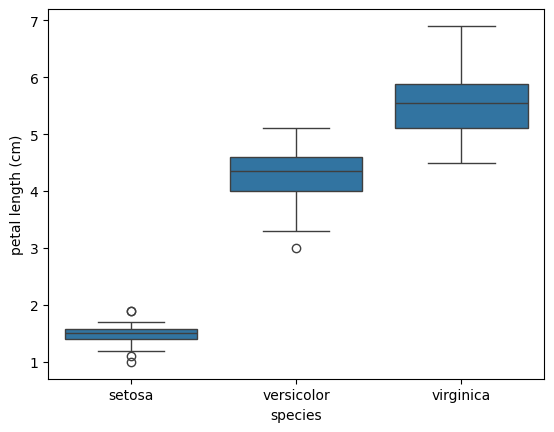

In [13]:
sns.boxplot(x="species",y="petal length (cm)",data=iris)
plt.show()

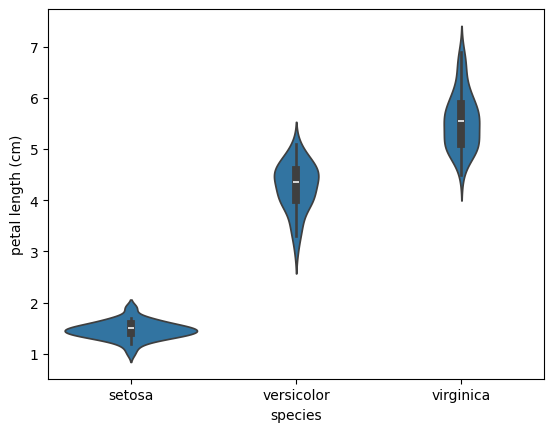

In [14]:
sns.violinplot(x="species",y="petal length (cm)",data=iris)
plt.show()

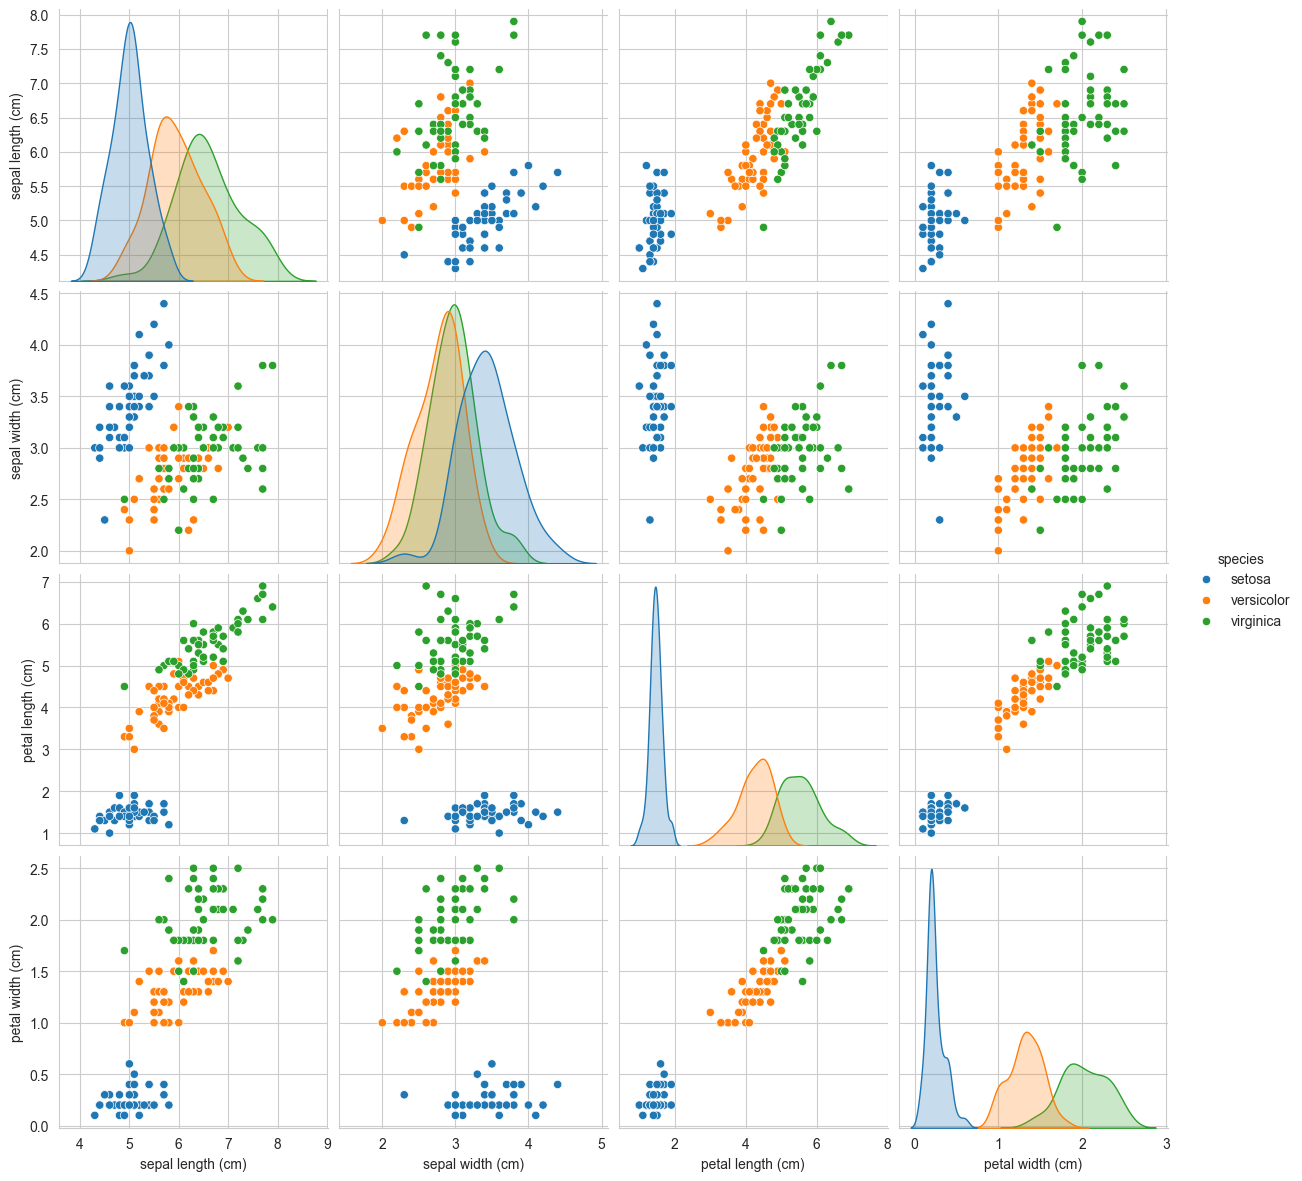

In [15]:
sns.set_style("whitegrid")
sns.pairplot(iris,hue="species",height=3);
plt.show()

## Criando o Modelo SVM

In [16]:
# Extraindo os 2 primeiros atributos para variáveis preditoras (x) e a variável target (y)
X = iris_sk.data[:, :2] 
y = iris_sk.target

Kernel: Temos várias opções disponíveis com kernel como, "linear", "rbf", "poly", "sigmoide", "precomputed" e outros.

O valor padrão é "rbf". Podemos alterar o padrão por meio do parâmetro kernel.

Os kernels "rbf" e "poli" são úteis para hiperplano não-linear. 

### SVM com Kernel Linear

Vamos explorar a aplicação do SVM (Support Vector Machine) com dois tipos de kernel, incluindo o kernel linear, utilizando dois atributos do conjunto de dados da íris para classificar suas classes. No outro exemplo vamos utilizar o RBF.

O SVM é um algoritmo de aprendizado de máquina amplamente utilizado para classificação e regressão. Ele funciona encontrando o hiperplano que melhor separa as classes no espaço de características. O kernel é uma parte fundamental do SVM, pois define a função de similaridade entre os pontos de dados no espaço de características.

Existem vários tipos de kernel no SVM, incluindo o kernel linear, o kernel polinomial, o kernel sigmoide e o kernel RBF (Radial Basis Function). Cada tipo de kernel tem suas próprias características e é adequado para diferentes tipos de dados e problemas.

Sugere-se o uso do kernel linear quando se tem um grande número de atributos (> 1000), pois é mais provável que os dados sejam linearmente separáveis no espaço de alta dimensão. O kernel linear é simples e eficiente, especialmente em conjuntos de dados com muitos atributos, onde a separação linear pode ser suficiente para classificar as classes com precisão.

In [17]:
# Depois de criar o modelo (Support Vector Classification) 
modelo_svc = svm.SVC(kernel = 'linear')
#fazemos fit dos dados
modelo_svc.fit(X,y)

SVC(kernel='linear')

**Criando um MeshGrid** 

Um meshgrid é uma estrutura de dados bidimensional utilizada principalmente em computação numérica e visualização de dados. Ele é comumente utilizado para criar uma grade retangular de pontos em um espaço de duas dimensões.

Em termos simples, um meshgrid é uma grade que consiste em dois arrays multidimensionais: um representando os valores das coordenadas ao longo do eixo x e outro representando os valores das coordenadas ao longo do eixo y. Esses arrays são então combinados para formar todas as possíveis combinações de pontos na grade.

O motivo pelo qual usamos um meshgrid para plotar é que muitas vezes precisamos calcular valores de uma função ou representar dados em uma grade regular. Por exemplo, ao plotar uma função bidimensional, como uma superfície tridimensional ou um mapa de contorno, é necessário ter uma grade regular de pontos sobre a qual calcular os valores da função.

Ao criar um meshgrid, podemos especificar os limites do domínio (intervalo ao longo do eixo x e ao longo do eixo y) e o número de pontos ao longo desses eixos. O resultado é uma grade de pontos uniformemente espaçados que cobre todo o domínio especificado.

Essa grade de pontos pode então ser usada para calcular os valores da função em cada ponto da grade. Em seguida, esses valores podem ser usados para criar uma visualização da função ou dos dados, como um gráfico de contorno ou uma superfície tridimensional. O meshgrid permite uma representação visual precisa e uniforme dos dados ou da função em um espaço bidimensional.

In [18]:
# Criando um meshgrid para o Plot
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = (x_max / x_min)/100
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Aqui, estamos definindo os limites do gráfico usando os mínimos e máximos dos atributos de comprimento e largura da sépala da íris. Em seguida, criamos um meshgrid usando 'np.meshgrid', que nos dá uma grade retangular de pontos uniformemente espaçados dentro desses limites.

*Criando a área de plotagem*

`plt.subplot(1, 1, 1)`

O comando plt.subplot(1, 1, 1) é utilizado para criar uma grade de subplots em uma figura do matplotlib. No caso específico desse comando, estamos criando apenas um subplot, ou seja, uma única área de plotagem. 
Os argumentos 1, 1, 1 indicam que queremos criar uma grade de subplots com 1 linha e 1 coluna, e que estamos nos referindo ao primeiro (e único) subplot dessa grade. Esses três números são usados para especificar a posição do subplot dentro da grad

*Fazendo previsões com o modelo SVM*

`Z = svc_model.predict(np.c_[xx.ravel(), yy.ravel()])`

Estamos usando o modelo SVM treinado (svc_model) para fazer previsões sobre todos os pontos do meshgrid.
Para isso, primeiro, a função 'np.c_' é usada para combinar os arrays xx e yy em um único array bidimensional, onde cada linha contém as coordenadas de um ponto

Em seguida, usamos 'ravel()' para transformar este array bidimensional em um array unidimensio

*Moldando os resultados para o formato meshgrid*

`Z = Z.reshape(xx.shape)`

Após fazer as previsões, remodelamos o array Z para que ele tenha a mesma forma que o meshgrid (xx.shape). Isso é necessário para que os resultados possam ser plotados corretamente sobre o meshgrid.

*Plotando o contorno da decisão de classificação*

`plt.contourf(xx, yy, Z, cmap = plt.cm.Paired, alpha = 0.8)`

Usando plt.contourf, plotamos os contornos preenchidos de acordo com as previsões feitas pelo modelo SVM sobre o meshgrid. Isso nos dá uma representação visual das regiões de decisão do classificador.

*Plotando os pontos de dados originais*

`plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.Paired)`

Aqui, estamos usando plt.scatter para plotar os pontos de dados originais do conjunto de dados da íris. Cada ponto é colorido de acordo com sua classe.

*Configurando os eixos e legendas*

`plt.xlabel('Sepal length')`

`plt.ylabel('Sepal width')`

`plt.xlim(xx.min(), xx.max())`

`plt.title('SVM / SVC com Kernel Linear')`

#Mostrando o Gráfico...

`plt.show()`
nal.ura.

Unindo todas as etapas acima...

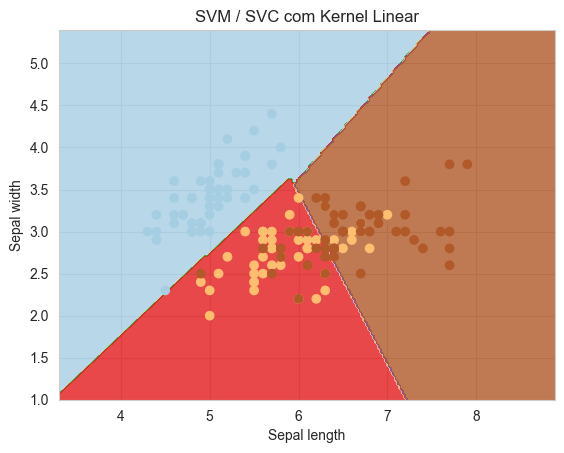

In [19]:
# Criando a área de plotagem
plt.subplot(1, 1, 1)
# Fazendo previsões com o modelo SVM
Z = modelo_svc.predict(np.c_[xx.ravel(), yy.ravel()])
# Moldando os resultados para o formato meshgrid
Z = Z.reshape(xx.shape)
# Plotando o contorno da decisão de classificação
plt.contourf(xx, yy, Z, cmap = plt.cm.Paired, alpha = 0.8)
# Plotando os pontos de dados originais
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.Paired)
# Configurando os eixos e legendas
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.title('SVM / SVC com Kernel Linear')
#Mostrando o Gráfico...
plt.show()

In [20]:
# Prever as classes para os dados de teste
y_pred = modelo_svc.predict(X)

# Calcular a acurácia
acuracia = accuracy_score(y, y_pred)
print("Acurácia do modelo SVC com kernel RBF:", acuracia)

Acurácia do modelo SVC com kernel RBF: 0.82


[[50  0  0]
 [ 0 38 12]
 [ 0 15 35]]


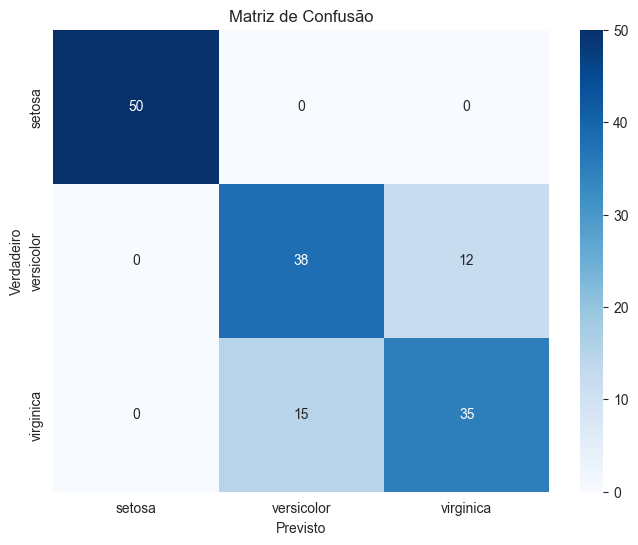

In [21]:
# Calcular a matriz de confusão
matriz_confusao = confusion_matrix(y, y_pred)
print(matriz_confusao)
# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap="Blues", fmt="d", xticklabels=iris_sk.target_names, yticklabels=iris_sk.target_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

### SVM com Kernel RBF

In [22]:
# Retreinando o Modelo com o Kernel RBF
modelo_svc2 = svm.SVC(kernel = 'rbf')
modelo_svc2.fit(X, y)

SVC()

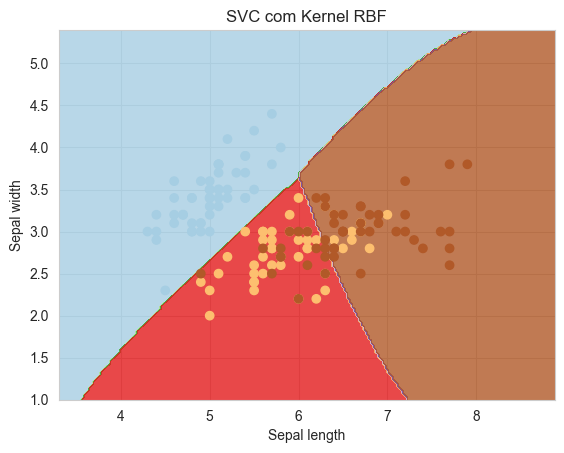

In [23]:
# Fazendo a mesma plotagem acima...
plt.subplot(1, 1, 1)
Z = modelo_svc2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap = plt.cm.Paired, alpha = 0.8)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.title('SVC com Kernel RBF')
plt.show()

A utilização do kernel RBF (Radial Basis Function) em máquinas de vetores de suporte (SVMs) traz consigo a necessidade de ajustar os parâmetros associados, como o parâmetro de regularização C e o parâmetro de largura de banda (gamma). 

A fim de evitar o overfitting, é crucial realizar a validação cruzada para otimizar esses parâmetros. 

O overfitting ocorre quando o modelo se ajusta excessivamente aos dados de treinamento, capturando padrões específicos desse conjunto que podem não ser generalizáveis para novos dados. 

Ao realizar a validação cruzada (cross-validation), dividimos o conjunto de dados em subconjuntos de treinamento e teste múltiplos, permitindo que o modelo seja avaliado em diferentes conjuntos de dados e garantindo uma melhor estimativa de seu desempenho em dados não vistos. 

Isso nos ajuda a escolher os valores ideais para os parâmetros do modelo, garantindo que ele generalize bem para novos dados, em vez de simplesmente memorizar os dados de treinamento. 

Em resumo, a validação cruzada é essencial ao ajustar os parâmetros do kernel RBF para SVMs, pois ajuda a evitar o overfitting e a construir modelos mais robustos e generalizáveis.

In [24]:
# Prever as classes para os dados de teste
y_pred2 = modelo_svc2.predict(X)

# Calcular a acurácia
acuracia = accuracy_score(y, y_pred2)
print("Acurácia do modelo SVC com kernel RBF:", acuracia)

Acurácia do modelo SVC com kernel RBF: 0.82


[[50  0  0]
 [ 0 38 12]
 [ 0 15 35]]


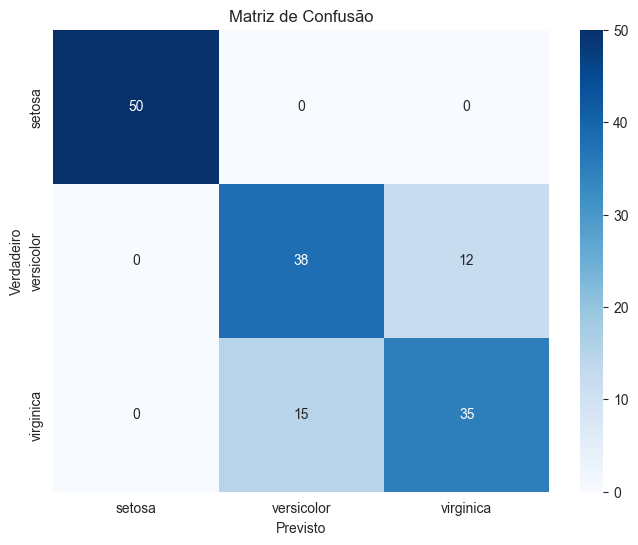

In [25]:
# Calcular a matriz de confusão
matriz_confusao = confusion_matrix(y, y_pred2)
print(matriz_confusao)
# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap="Blues", fmt="d", xticklabels=iris_sk.target_names, yticklabels=iris_sk.target_names)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

## Fim do Projeto 16